# Prediction of stop 1000 GeV in DM channel 3

In [1]:
# In case of problems with importing libraries in this cell
# Go to "Softwares" (blue cube symbol on the left)
# Load scipy-stack/2023a StdEnv/2020 gcc/9.3.0
# then re-select the Python 3.9 kernel on the top right 

import re

import numpy as np
import pandas as pd
import csv

from pathlib import Path
from tqdm import tqdm
from seaborn import heatmap
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

/cvmfs/soft.computecanada.ca/easybuild/software/2020/avx512/Core/scipy-stack/2022a/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.25.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Config

Configure which sample to analyse

In [8]:
samples = {'stop' : 'stlp/stlp_st1000_chan3',
           'stop_cut': 'stlp/stlp_st1000_chan3_cuts',
           'Wprime_qqvv_100000' :'Wprime/Wprime_qqvv_HVT_chan3_100000',
           'Wprime_lvqq_100000' : 'Wprime/Wprime_lvqq_HVT_chan3_100000',
           'Wprime_qqvv_10000': 'Wprime/Wprime_qqvv_HVT_chan3_10000',
           'Zprime_pp23' : 'Zprime/pp23mt_50_chan2b',
           'Zprime_pp24' : 'Zprime/pp24mt_50_chan2b',
           'LQ_bmubmu_1000' : 'LQ/LQ_bmubmu_600_chan2b_1000',
           'LQ_bmubmu_100' : 'LQ/LQ_bmubmu_600_chan2b_100',
           'LQ_bmubmu_10' : 'LQ/LQ_bmubmu_600_chan2b_10',
           'LQ_bebe_1000' : 'LQ/LQ_bebe_600_chan2b_1000',
           'LQ_bebe_100' : 'LQ/LQ_bebe_600_chan2b_100',
           'LQ_bebmu_1000' : 'LQ/LQ_bebmu_600_chan2b_1000',
           'LQ_bebmu_100':'LQ/LQ_bebmu_600_chan2b_100',
           'LQ_bebmu_10' : 'LQ/LQ_bebmu_600_chan2b_10',
           'LQ_tlbv_chan3_800000': 'LQ/LQ_tlbv_test_1300_chan3_800000',
            'bkg_chan3': 'bkg/background_chan3',
           'bkg_chan2b': 'bkg/background_chan2b'}
sample = 'stop'
channel = 'bkg_chan3'
analysis = '15'

In [9]:
config = {
    "datasets" : [
        {
        'output_dir' : f'../bump_hunting_analysis{analysis}/memoire_plot',
        'bkg_input_dir' : f'../bump_hunting_analysis{analysis}/{samples[sample]}',
        'bkg_prediction_dir' : f'../bump_hunting_analysis{analysis}/{samples[sample]}',
        'sig_input_dir': f'../bump_hunting_analysis{analysis}/{samples[sample]}',
        'sig_prediction_dir':f'../bump_hunting_analysis{analysis}/{samples[sample]}',
        'smooth_dir' : f'../bump_hunting_analysis{analysis}/{samples[sample]}_ethans_raw_smoothing',
        'blacklist_dir':'./'
        }
    ]}

# Functions

### Utility Functions

In [10]:
def Gauss(x, a, x0, sigma):
    """Used to perform certain gaussian fits."""
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def flatten(matrix):
    """Flattens a multi-dimensionnal matrix into a list"""
    flat_list = []
    for row in matrix:
        flat_list.extend(row)
    return flat_list

remove_NaN = lambda row : row[np.isfinite(row)]

### Family
The *Family* class is used whith the global analysis algotihm. A family is basically a gorup of histograms that peak around the same place and that may or may not be exclusively uncorrelated.

Some class methods require passing a *PerformanceUtilBSM* instance as an argument.

In [11]:
class Family():
    """
    A class to represent a group of histograms.

    Attributes
    ----------
    mass_bounds : tuple
        A tuple of 2 oredered mass values defininf the bounds for which new histograms may be added in the Family
    seed : int
        Integer representing the index of the seed histogram in the PerformanceUtilBSM class
    histograms : int
        List of indexes representing the histograms. Indexes should be used with lists from the PerformanceUtilBSM class
    Methods
    -------
    add_histograms:
        Manually add a histogram index in the Family
    size:
        Returns the size of the Family in terms of histograms
    plot_histograms:
        Plot the histogram of a certain family. Needs to pass the PerformanceUtilBSM instance as an argument.
    signal_gaussian_fit:
        Performs a gaussian fit of the signal for a certain histogram. Needs the PerformanceUtilBSM instance as an argument.
    """
    def __init__(self, mass_bounds=None, seed=None):
        self.mass_bounds = mass_bounds
        self.seed = seed
        if seed is not None:
            self.histograms = [seed]
        else:
            self.histograms = []
        
    def add_histogram(self, hist):
        self.histograms.append(hist)
        
    def size(self):
        return len(self.histograms)

    def plot_histograms(self, bsm, save=True, plot_fit=False):
        for hist in self.histograms:
            fig, ax = bsm.get_example(hist)
            print(bsm.c[hist])
            if plot_fit:
                fit, _ = self.signal_gaussian_fit(hist, bsm=bsm)
                ax[1].errorbar(bsm.n[hist], fit, drawstyle='steps-mid')
            if save:
                fig.savefig(fname=f"{config['datasets'][0]['output_dir']}/{hist}.png")
                
    def signal_gaussian_fit(self, hist, bsm):
        signal = bsm.s[hist]
        signal_binning = list(range(len(bsm.n[hist])))
        max_position = np.argmax(signal)
        popt, pcov = curve_fit(Gauss, signal_binning[max_position-5:max_position+5], signal[max_position-5:max_position+5], p0=[max(signal), signal_binning[np.argmax(signal)], 5])
        func = Gauss(signal_binning, *popt)
        return func, popt

### PerformanceUtilBSM
This class is the main part of this file. It is derived from the *PerformanceUtil* class found in the BumpNet framework, but modified to handle BSM

In [26]:
class PerformanceUtilBSM():
    """Class used to load a BSM samples and perform various actions on it
    Attributes
    ---
    self.(letter) : Various BSM files. As an example, self.x corresponds to the observed value of the histograms
    self.blacklist: A list that containes some blacklisted histograms. Used in some scenario.
    self.n_hists  : Number of histograms in the sample.
    ---

    Methods:
    ---
    self.trim_histograms : Removes histograms according to certain parameters
    self.load_data : Utility method used in initialisation to load files
    self.remove_blacklist: Remove histograms in the blacklist from the sample 
    self.get_signature_and_observables: Get signature and observable from a histogram.
    self.get_predictions_heatmap: Generates and plot a heatmap of the predictions.
    self.get_example: Generates and plots a particular histogram.
    self.find_mass_bounds: Finds the "mass bounds" of the bump in an histogram
    self.perform_global_analysis_algorithm: Performs the GAA on the sample
    self.do_gaussian_fits_on_signal_group: Performs gaussian fits on the signal of histograms in a single family
    self.plot_families_content: Plot the individual histograms of a family
    self.plot_families: Plots a figures that shows the different sizes of all the families
    self.trim_families: Removes families that are small (<1)
    self.get_simplified_observables: Returns a simplified version of the observables
    self.restrict_objects: Performs a vote on simplified objects of histograms in a family and removes histograms that don't pass the vote
    self.family_is_correlated: Determines if a family is completely correlated
    ---
    """
    
    def __init__(self, input_dir, prediction_dir=None, smooth_dir=None,
                verbose=False, max_rows=None, edge=(0,1), remove_massT = True,
                blacklist_dir=None, trimming=False, min_events=0, min_bins=0):
        
        # Load files from data samples
        for n in ['x', 'b', 's', 'i', 'm', 'c']:
            try:
                # Loads data
                loaded_data = self.load_data(input_dir,
                                            n.upper(),
                                            verbose=verbose, max_rows=max_rows)
            except:
                loaded_data = None
                print(f'Could not load data for {n}. Setting it to None.')
            setattr(self, n, loaded_data)

        # prediction_dir should be the directory where the predictions are held
        self.z_pred = self.load_data(prediction_dir, 'z', verbose=verbose, max_rows=max_rows) if prediction_dir else None
        self.b_pred = self.load_data(prediction_dir, 'b', verbose=verbose, max_rows=max_rows) if prediction_dir else None

        # This is the signal. In the files I had the format was different and needed reformatting
        # Remove if not necessary
        if self.s is not None:
            self.s = np.array([remove_NaN(np.array(row).astype(float)) for row in self.s], dtype=object)
        
        # We remove histograms with the "massT" observable
        if remove_massT:
            mask = np.array(["massT" in cat[0] for cat in self.c])
            self.c = np.ma.masked_array(self.c, mask).compressed()
            self.c = np.array([cat for cat in self.c])

            self.x = np.ma.masked_array(self.x, mask).compressed()
            self.m = np.ma.masked_array(self.m, mask).compressed() 
            self.s = np.ma.masked_array(self.s, mask).compressed() if self.s is not None else None
            self.z_pred = np.ma.masked_array(self.z_pred, mask).compressed() if self.z_pred is not None else None

        # If you smoothed the bkg of the BSM samples, you can load it. The attributes will get set as self.(letter)_smooth.
        if smooth_dir is not None:
            for n in ['b', 'c', 'm', 'z_pl']:
                try:
                    loaded_data = self.load_data(smooth_dir,
                                                n.upper() if n != 'z_pl' else 'Z', verbose=verbose, max_rows=max_rows)
                except:
                    loaded_data = None
                    print(f'Could not load data for {n}. Setting it to None.')
                setattr(self, n + "_smooth", loaded_data)

        # Load blacklist if it exist
        self.blacklist = self.load_data(blacklist_dir, f'blacklist_smooth_{channel}', verbose=verbose, max_rows=max_rows) if blacklist_dir else None
        
        if verbose and (self.blacklist is not None):
            print("Size before blacklist:", self.x.size)
            if self.blacklist is not None:
                self.remove_blacklist()
            print("Size after blacklist:", self.x.size)

        if trimming:
            print("Before trimming:", self.x.shape[0])
            self.trim_histograms(min_events, min_bins)
        

        self.n_hists = self.x.shape[0]
        if verbose:
            print("There are ", self.n_hists, "histograms")

        
        # Set various attributes
        attribute_names = ['n_bins', 'start_bin', 'last_bin',
                        'z_pred_max', 'z_pred_max_bin',
                        'mass_pred', 'z_inj'
                            ]
        
        attrs = {name:[] for name in attribute_names}
        for i in range(self.n_hists):
            obs = self.x[i]
            attrs['n_bins'] += [len(obs)]

            # Values for considered bins. This is usually (0.1 and 1)
            start_bin = int(np.ceil(edge[0] * len(obs)))
            last_bin = int(np.ceil(edge[1] * len(obs)))

            if self.s is not None:
                s = self.s[i]
                attrs['z_inj'] += [np.argmax(s)]

            if self.z_pred is not None:
                zpred = self.z_pred[i]
                mass = self.m[i]
                attrs['z_pred_max'] += [np.max(zpred[start_bin:last_bin])]
                attrs['z_pred_max_bin'] += [start_bin+np.argmax(zpred[start_bin:last_bin])]
                attrs['mass_pred'] += [mass[start_bin+np.argmax(zpred[start_bin:last_bin])]]

        for n in attribute_names:
            if len(attrs[n]) == 0:
                setattr(self, n, None)
            else:
                setattr(self, n, np.array(attrs[n]))

    def trim_histograms(self, min_events, min_bins):
        """Removes the histograms that don't have at least *min_events* and *min_bins*"""
        indices = []
        for idx, row in enumerate(self.x):
            x0 = row[0]
            i = 0
            while x0>=5:
                i+=1
                x0 = row[i]
            self.x[idx] = row[:i]
            if self.x[idx].size < min_bins:
                indices.append(idx)
            self.m[idx] = self.m[idx][:i+1]
            self.n[idx] = self.n[idx][:i]
            self.s[idx] = self.s[idx][:i]
            self.z_pred[idx] = self.z_pred[idx][:i]
            
        self.c = np.delete(self.c, indices)
        self.d = np.delete(self.d, indices)
        self.m = np.delete(self.m, indices)
        self.n = np.delete(self.n, indices)
        self.x = np.delete(self.x, indices)
        self.s = np.delete(self.s, indices)
        if self.z_pred is not None:
            self.z_pred = np.delete(self.z_pred, indices)    
    
    def remove_blacklist(self):
        """If you have loaded a blacklist, remove the histograms from the sample that are also in the blacklist"""
        _, _, indices = np.intersect1d(self.blacklist, self.c, return_indices=True)
        self.c = np.delete(self.c, indices)
        self.m = np.delete(self.m, indices)
        self.x = np.delete(self.x, indices) 
        self.s = np.delete(self.s, indices) if self.s is not None else None
        self.z_pred = np.delete(self.z_pred, indices) if self.z_pred is not None else None
    
    def load_data(self, which_dir, which_data, verbose, max_rows):
        """Utility function to load the different files"""
        path = list(Path(which_dir).glob(f'**/*{which_data}*.*'))[0] 
        if path.suffix == '.npy':
            data = np.load(str(path), allow_pickle=True)
        elif path.suffix == '.csv':
            # If the data is text, we need to load it differently
            if which_data in ['C', 'blacklist_smooth_bkg_chan2b', 'blacklist_smooth_bkg_chan3']:
                data = np.loadtxt(str(path), delimiter=',', dtype=str, max_rows=max_rows)
                data = np.array([np.array([row]) for row in data], dtype=object)
            else:
                data = []
                with open(str(path), 'r') as csv_file:
                    csv_reader = csv.reader(csv_file, delimiter=',')
                    for row in csv_reader:
                        data += [np.array([float(i) for i in row if i != ''])]
                        if max_rows is not None and len(data) >= max_rows: break
                data = np.array(data, dtype=object)
        else:
            print(f'Could not load data in appropriate format: {str(path)}.')
            return None
        if verbose:
            print(f'Loaded {which_data} from {which_dir}')
        return data

    def get_signature_and_observable(self, histogram_name):
        '''Gets the histogram final state and observable from its name.
        Returns strings in LaTeX for the signature and observable, respectively.'''
        # Histograms from DarkMachines and ATLAS
        if 'hCat' in histogram_name:
            # Signature
            object_patterns = {
                r'$\gamma$':r'_\d+g_',
                r'$e$':r'_\d+e_',
                r'$\mu$':r'_\d+m_',
                r'Wh':r'_\d+Wh_',
                r'T':r'_\d+T_',
                r'HM':r'_\d+HM_',
                r'Z':r'_\d+Z_',
                r'b':r'_\d+bExc_',
                r'j':r'_\d+ex_',
                r'+j':r'_\d+in_',
            }
            objects = {}
            for obj, pattern in object_patterns.items():
                element = re.findall(pattern, histogram_name)
                if len(element) == 0:
                    # print(f'Could not find pattern {pattern} in {histogram_name}')
                    continue
                objects[obj] = re.findall(r'\d+', element[0])[0]

            signature = ' + '.join([f'{n}{obj}'  for obj, n in objects.items() if n != '0'])

            cuts = ['OS', 'SS',
                    '200met', '500met',
                    '100E0pt', '200E0pt',
                    '100M0pt', '200M0pt', '400M0pt',
                    '200G0pt', '400G0pt',
                    '100Z0pt', '200Z0pt',
                    '200Wh0pt', '500Wh0pt', '1000Wh0pt',
                    '500T0pt', '1000T0pt',
                    '500HM0pt', '1000HM0pt'
                    ]
            for pattern in cuts:
                if len(re.findall(pattern, histogram_name)) != 0:
                    signature += f', {pattern}'

            # Observable
            observable = ''
            if len(re.findall('massMET', histogram_name)) != 0:
                observable += r'$m(E_{Tmiss},'
            elif len(re.findall('mass', histogram_name)) != 0:
                observable += r'$m('
            else:
                raise Exception('Could not identify observable in histogram name.')
            combination = histogram_name.split('__')[1].split('_')[0]
            replacements = {'.':',', 'el':'e', 'mu':'\\mu', 'top':'T'}
            for str_in, str_out in replacements.items():
                combination = combination.replace(str_in, str_out)
            observable += combination
            observable += ')$'

        return signature, observable

    def get_predictions_heatmap(self, title='', text='', threshold=5, indices = None, plot_params = (50, 2150, 100)):
        """Generate the figure for the heatmap of the prediction above a threshold of significance
        The function also allows the user to restrict which predictions are plotted through the *indices*
        argument, which should be a list of desired indices (None if you want all predictions).

        The *plot_params* argument should contain 3 numbers, the start of the heatmap'energy, the end and the binnning
        Default values are 50, 2150, and 100 GeV.
        """
        # Get heatmap data
        if indices is None:
            df_data = np.array([self.z_pred_max, self.mass_pred]).T
        else:
            df_data = np.array([self.z_pred_max[indices], self.mass_pred[indices]]).T
            
        columns = ['zmax', 'mass']
        df = pd.DataFrame(data=df_data, columns=columns)
        
        xdata = df[(df['zmax'] >= threshold)]['zmax'].to_numpy()
        ydata = df[(df['zmax'] >= threshold)]['mass'].to_numpy()

        x_binning = np.arange(threshold, threshold+10, 1)
        y_binning = np.arange(plot_params[0], plot_params[1], plot_params[2])

        # Create figure
        fig, ax = plt.subplots(figsize=(6, 4.5), dpi=200, layout='tight')
        heatmap_data, x_binning, y_binning = np.histogram2d(xdata, ydata, bins=[x_binning, y_binning])
        ax = heatmap(heatmap_data.T, annot=True, annot_kws={"size": 8}, fmt='.3g',cmap='Blues', cbar_kws={'label': "Number of histograms"})
        ax.set_xlabel('$Z_{\mathrm{max}}^{\mathrm{pred}}$')
        ax.set_ylabel('Predicted mass ($m_{\mathrm{pred}}$)')
        plt.xticks(np.arange(len(x_binning)), [f'{i}' for i in x_binning], rotation='horizontal', fontsize=8)
        plt.yticks(np.arange(len(y_binning)), [f'{i}' for i in y_binning], rotation='horizontal', fontsize= 8)    

        return fig, ax
        
    def get_example(self, i, use_bin_centers=True, title=None,
                    z_prediction=True, bkg_prediction=False, show=False, plot_smooth=False):
        """Returns the figure of a singular histogram
        Args:
            z_prediction (bool) : True if you want to plot the prediction
            bkg_prediction (bool) : True if you want to plot the bkg_prediction
            show (bool) : True if you want to show the histogram
            plot_smooth (bool) : If you have loaded the smoothed version of the bkg, you can plot it here.
        """
        obs = self.x[i] #observed
        bkg = self.b[i] if self.b is not None else None #background
        zpred = self.z_pred[i] if self.z_pred is not None else None #predicted z
        if not z_prediction:
            zpred = None
        bpred = self.b_pred[i] if self.b_pred is not None else None #predicted b
        
        sig = self.s[i] if self.s is not None else None #signal
        sig_factor = self.i[i,1] if self.i is not None else None #scaling factor for the signal
        mu = self.i[i,0] if self.i is not None else None #significance of the signal
        mass_binning = self.m[i] if self.m is not None else None
        bin_centers = (mass_binning[:-1]+mass_binning[1:])/2 if (mass_binning is not None and use_bin_centers) else None
        bin_widths = np.diff(mass_binning) if (mass_binning is not None and use_bin_centers) else None
        hist_name = self.c[i] if not title else title

        signature, observable  = self.get_signature_and_observable(hist_name)

        nrows = 1
        if sig is not None: nrows += 1
        if zpred is not None: nrows += 1
        gridspec_kw = {'height_ratios': [2] + [1]*(nrows-1), 'hspace': 0.05} if nrows != 1 else {}
        fig, ax = plt.subplots(nrows=nrows, ncols=1, figsize=(6, 6), dpi=200,
                               sharex=True, gridspec_kw=gridspec_kw)

        # Main plot
        xlabel = observable+' [GeV]' if bin_centers is not None else 'Bins'
        bin_centers = bin_centers if bin_centers is not None else np.arange(1, len(obs)+1) + 0.5
        bin_widths = bin_widths if bin_widths is not None else np.ones(bin_centers.shape[0])

        ax[0].errorbar(bin_centers, obs, label='Observé', # xerr=bin_widths/2,
                       color='black', linewidth=1,
                       yerr=np.sqrt(obs), ecolor='black', elinewidth=0.5, capsize=2, capthick=0.5,
                       drawstyle='steps-mid')

        if bkg is not None:
            ax[0].errorbar(bin_centers, bkg, label='Background', color='tab:orange', linewidth=1)
        if bkg_prediction and bpred is not None:
            ax[0].errorbar(bin_centers, bpred, label='Predicted background', color='tab:red', linewidth=1,
                        drawstyle='steps-mid')

        ax[0].set_ylabel('Events', loc='top')

        # Observed - background plot, if applicable
        # ax[1].errorbar(bin_centers, sig * sig_factor, label=f'Signal $\u00D7$ {sig_factor:.2e}',
        if sig is not None:
            if bkg is not None:
                ax[1].bar(bin_centers, obs - bkg, width=bin_widths, label='Obs - bkg',
                          color='#d3d3d3', edgecolor='#d3d3d3')
    
            ax[1].errorbar(bin_centers, sig, label='Signal',
                           color='tab:green', linewidth=1, drawstyle='steps-mid')
            ax[1].axhline(y=0, color='black', linewidth=1)
            ax[1].set_ylabel('Events', loc='top')


        # Significance plot, if applicable
        k = 1 if (sig is None) or (zpred is None) else 2
        if z_prediction and zpred is not None:
            ax[k].errorbar(bin_centers, zpred,
                           label='BumpNet ' + r'($Z_{max}$ = '+f'{np.nanmax(zpred):.1f})',
                           color='tab:red', linewidth=1, drawstyle='steps-mid')
            ax[k].axvline(bin_centers[np.argmax(zpred)], color='tab:red', linestyle='--', linewidth='0.5')
        ax[k].axhline(color='black', linewidth=0.7)
        if zpred is not None:
            ymin_zp = np.nanmin(zpred)
            ymax_zp = np.nanmax(zpred)
            factor = 1.5 if ymax_zp > 5 else 3
            ymin = factor*ymin_zp
            ymax = factor*ymax_zp
            ax[k].set_ylim(ymin, ymax)
        ax[k].set_xlabel(xlabel, loc='right')
        if k == 2:
            ax[k].set_ylabel('Signification', loc='top')
        else:
            ax[k].set_ylabel('Évènements', loc='top')

        for i, axis in enumerate(ax):
            if i not in [0]: continue
            y_axis_format = ScalarFormatter(useMathText=True)
            y_axis_format.set_powerlimits((0, 0))
            axis.yaxis.set_major_formatter(y_axis_format)

        for k in range(nrows):
            if k == 0:
                ax[k].legend(loc='upper right', ncol=[1,2,2][k], columnspacing=0.1, frameon=False,
                             title=signature) # , fontsize=8)
            else:
                ax[k].legend(loc='upper right', ncol=[1,2,2][k], columnspacing=0.1, frameon=False)#,
                             # fontsize=8)
            ax[k].xaxis.set_minor_locator(AutoMinorLocator())
            ax[k].yaxis.set_minor_locator(AutoMinorLocator())
            ax[k].tick_params(axis='x', which='both', direction='in', bottom=True, top=True)
            ax[k].tick_params(axis='y', which='both', direction='in', left=True, right=True)
            ax[k].tick_params(which='major', axis='both')
            ax[k].tick_params(which='minor', axis='both')

        if plot_smooth:
            smooth_idx = np.where(self.c_smooth == hist_name)
            print(smooth_idx[0])
            if smooth_idx[0].size == 0:
                print("Oh no")
            
            if smooth_idx[0].size > 0:
                print("Continue")
                smooth_obs = self.b_smooth[smooth_idx]
                # smooth_obs = smooth_obs[smooth_obs!=None]
                # smooth_obs = smooth_obs[np.isfinite(smooth_obs)]
                smooth_bins = self.m_smooth[smooth_idx][0]
                smooth_zpl = self.z_pl_smooth[smooth_idx][0]
                smooth_zpl =smooth_zpl[smooth_zpl!=None]
                maxzpl = max(smooth_zpl)
                size = min(smooth_obs.size, smooth_bins.size)
                print(smooth_obs.size)
                print(smooth_bins.size)
                smooth_bin_centers = (smooth_bins[:-1]+smooth_bins[1:])/2
                ax[0].errorbar(smooth_bin_centers[:size], smooth_obs[:size], color='orange', zorder=100, label='Smoothing',drawstyle='steps-mid')
                ax[1].errorbar(smooth_bin_centers[:size], smooth_zpl[:size], color='blue', zorder=50, label=f"PLR (max={maxzpl:.2f})", drawstyle='steps-mid')

        if show: plt.show()

        return fig, ax

    def find_mass_bounds(self, i, resolution=1):
        """
        Used to find the "bounds" of a bump in a histogram. it returns the mass values
        containing the bump up to "resolution" bins
        """
        # First find the bins that define the mass region
        bin_centers = (self.m[i][:-1]+self.m[i][1:])/2
        try:
            mass_min, mass_max = bin_centers[self.z_pred_max_bin[i] - resolution], bin_centers[self.z_pred_max_bin[i] + resolution]
        except:
            if self.z_pred_max_bin[i] == 0:
                mass_min, mass_max =  bin_centers[0], bin_centers[self.z_pred_max_bin[i] + resolution]
            if self.z_pred_max_bin[i] in [self.n_bins[i] - k for k in list(range(1, resolution+1))]: # OK
                mass_min, mass_max = bin_centers[self.z_pred_max_bin[i] - resolution], bin_centers[-1]
            else:
                print("ERROR")
                print([self.n_bins[i] - k for k in list(range(1, resolution+1))])
                print(f"Max zpred bin = {self.z_pred_max_bin[i]}")
                print(f"nbins = {self.n_bins[i]}")
        return mass_min, mass_max
        
    def perform_global_analysis_algorithm(self, verbose=True, bin_resolution=1, sigma_threshold=5):
        """
        Performs the global analysis algorithm and returns the list of families
        Args:
            bin_resolution (int) : Width, in bins, of the "similarity" between predicted masses.
            sigma_threshold (int) : minimum predicted significance for which bumps are considered
        """
        # First we find the seed histograms. We do this by getting a list of all histograms indices
        # that pass the 5 sigma cut.
        families = []
        indices = list(range(0, len(self.z_pred_max)))
        # The value 5 here is hard-coded
        seeds = np.ma.masked_where(self.z_pred_max.reshape(-1,) <= 5, indices).compressed()
    
        # Also find a list of histograms  that peak above a certain threshold and that will be allowed
        # to populate the bump groups:
        preds_above_threshold = np.ma.masked_where(self.z_pred_max.reshape(-1,) <= sigma_threshold, indices).compressed()
        if verbose:
            print(f"There are {len(seeds)} seeds")
            
        mass_bounds = []
        # Now, for each seed, we want to identify mass bounds:
        for seed in seeds:
            # First find the mass where the seed peaks and check to see if this is already covered
            if len(mass_bounds):
                mass = self.mass_pred[seed]
                mass_peaks_inside_existing_bounds = np.array([(mass > bounds[0]) and (mass < bounds[1]) for bounds in mass_bounds])
                if mass_peaks_inside_existing_bounds.any():
                    continue
            bound_min, bound_max = self.find_mass_bounds(seed, bin_resolution)
            mass_bounds.append((bound_min, bound_max))
    
            # *************** #
            f = Family(mass_bounds=(bound_min, bound_max), seed=seed)
            families.append(f)
    
        # Create the new seed list
        seeds = []
        for f in families:
            seeds.append(f.seed)
            
        for hist in preds_above_threshold:
            mass = self.mass_pred[hist]
            if hist in seeds:
                continue
            which_mass_bounds = [(mass > bounds[0]) and (mass < bounds[1]) for bounds in mass_bounds]
            which_mass_bounds = [i for i, x in enumerate(which_mass_bounds) if x]
            for idx in which_mass_bounds:
                families[idx].add_histogram(hist)
        self.families = families
        self.seeds = seeds
        return families, seeds

    def do_gaussian_fits_on_signal_group(self, fam_idx):
        """
        Perform gaussian fits on the signal group of index idx in the families list
        """
        gaussian_fits = []
        for hist in self.families[fam_idx]:
            signal = self.bsm.s[hist]
            signal_binning = list(range(len(self.bsm.n[hist])))
            popt, pcov = curve_fit(Gauss, signal_binning, signal, p0=[max(signal), signal_binning[np.argmax(signal)], 5])
            func = Gauss(signal_binning, *popt)
            gaussian_fits.append(func)
        self.signal_group_gaussian_fits = gaussian_fits
    
    def plot_families_contents(self, indices, plot_fits = False, save=False, smooth=False):
        """Plots the families of a particular group
        Args:
            indices (list) : List of indices of families we want to plot the histograms.
            plot_fits (bool) : True if you want to plot the signal's gaussian fit in the plots
            save (bool) : True if you want to save the plots
            smooth (bool) : True of you want to plot the smoothed bkg
        """
        for idx in indices:
            for i, hist in enumerate(self.families[idx].histograms):
                print(hist, self.c[hist])
                fig, ax = self.get_example(hist, plot_smooth=smooth)
                if plot_fits:
                    fit = self.signal_group_gaussian_fits[i]
                    ax[1].errorbar(self.bsm.n[hist], fit, drawstyle='steps-mid')
                if save:
                    fig.savefig(fname=f"{config['datasets'][0]['output_dir']}/{hist}.png", bbox_inches='tight')

    def plot_families(self):
        """Creates a bar plot showing the size of each family according to it's mass bounds """
        fig, ax = plt.subplots()
        families_indices = list(range(len(self.families)))
        families_mass_range = []
        for fam in self.families:
            min, max = fam.mass_bounds
            families_mass_range.append(f"[{min}, {max}]")
        hist_per_family = [fam.size() for fam in self.families]
                
        rects = ax.bar(families_mass_range, hist_per_family)
        ax.bar_label(rects, hist_per_family)
        ax.set_xticklabels(families_mass_range, rotation=30, ha='right', fontsize=8)
        ax.set_xlabel("Groups")
        ax.set_ylabel("# of entries")
        ax.set_title("Entries per group")
        ax.tick_params(which="both", direction="in")
        return fig, ax

    def trim_families(self):
        """Removes family with one hist from the instance's family list"""
        self.families = [fam for fam in self.families if fam.size() > 1]

    def get_simplified_observables(self, objects):
        """Given a set of objects, return some simplified observable based on object's type
        An electron and a muon, for example, are considered to be the "same" object. 
        """
        objs = objects.split(',')
        x, y, z, a, b = 0 ,0 ,0 ,0 ,0
        for obj in objs:
            if obj == 'E_{Tmiss}':
                x += 1
            if (obj[0] == 'j') or (obj[0] == 'b') or (obj[:-1] == 'lj'):
                y += 1
            if obj[0] == 'e':
                z += 1 
            if obj[:-1] == '\\mu':
                z += 1
            if obj[:-1] == 'Wh':
                a += 1
        return f"{x}MET+{y}j+{z}l+{a}Wh0" 

    def restrict_objects(self):
        """For all families, perform a vote on the object type. The object type with the most vote becomes the dominant
        objects for this family and all histograms that do not possess these objects are removed from the family.
        """
        new_families = []
        for family in self.families:
            new_family = Family(mass_bounds=family.mass_bounds)
            names = self.c[family.histograms]
            objects = {}
            for hist in names:
                sig, obs = self.get_signature_and_observable(hist)
                # Remove $m( ... )$
                obs = self.get_simplified_observables(obs[3:-2])
                # print(obs)
                if obs in objects.keys():
                    objects[obs] +=1
                else:
                    objects[obs] = 1
            winner = max(objects, key=objects.get)
            for hist, i in zip(names, family.histograms):
                sig, obs = self.get_signature_and_observable(hist)
                if self.get_simplified_observables(obs[3:-2]) == winner:
                    new_family.add_histogram(i)
            new_families.append(new_family)
        self.families = new_families

    def family_is_correlated(self, family):
        """Determines if a family consist of uncorrelated histograms"""
        jets, objs, types = [], [], []
        for h in family.histograms:
            name = self.c[h]
            index = 9
            if name.split("_")[8] == "OS" or name.split("_")[8] == "SS":
                index += 1
            jet, obj, _type = name.split('_')[index], name.split('_')[index+2], name.split('_')[index+3]
            jets.append(jet)
            objs.append(obj)
            types.append(_type)
        jets, objs, types = np.array(jets), np.array(objs), np.array(types)
        jets = np.unique(jets)
        objs = np.unique(objs)
        types = np.unique(types)
        # print(jets.size)
        if (types.size==1) and (jets.size==1) and (objs.size==1):
            return True
        return False
        
    def remove_correlated_families(self):
        """Removes completely correlated families from the instance's families list"""
        indices_to_remove = []
        for i, f in enumerate(self.families):
            # print(self.family_is_correlated(f))
            if self.family_is_correlated(f):
                indices_to_remove.append(i)
        self.families = np.delete(self.families, indices_to_remove)

In [27]:
# Create an instance of a BSM sample analysis. This is named stop because it's the first one I did
# YOu can rename it or create other ones.
stop = PerformanceUtilBSM(config["datasets"][0]["sig_input_dir"], # Dir of the signal
                        prediction_dir=config["datasets"][0]["sig_input_dir"], # Dir where the prediction is held   
                        verbose=True, # If you want to see more comments
                        max_rows=None,
                        edge=(0.10, 1), # Considered bins in an histogram. This ignores the first 10%
                        remove_massT=True, # If you want to remove the massT histograms
                        blacklist_dir = config['datasets'][0]['blacklist_dir'],
                        smooth_dir = None # config['datasets'][0]['smooth_dir'],
                         )
print("Done")

Loaded X from ../bump_hunting_analysis15/stlp/stlp_st1000_chan3
Could not load data for b. Setting it to None.
Loaded S from ../bump_hunting_analysis15/stlp/stlp_st1000_chan3
Could not load data for i. Setting it to None.
Loaded M from ../bump_hunting_analysis15/stlp/stlp_st1000_chan3
Loaded C from ../bump_hunting_analysis15/stlp/stlp_st1000_chan3
Loaded z from ../bump_hunting_analysis15/stlp/stlp_st1000_chan3
Loaded b from ../bump_hunting_analysis15/stlp/stlp_st1000_chan3
Loaded blacklist_smooth_bkg_chan3 from ./
Size before blacklist: 42386
Size after blacklist: 42122
There are  42122 histograms
Done


### Plot the Heatmap

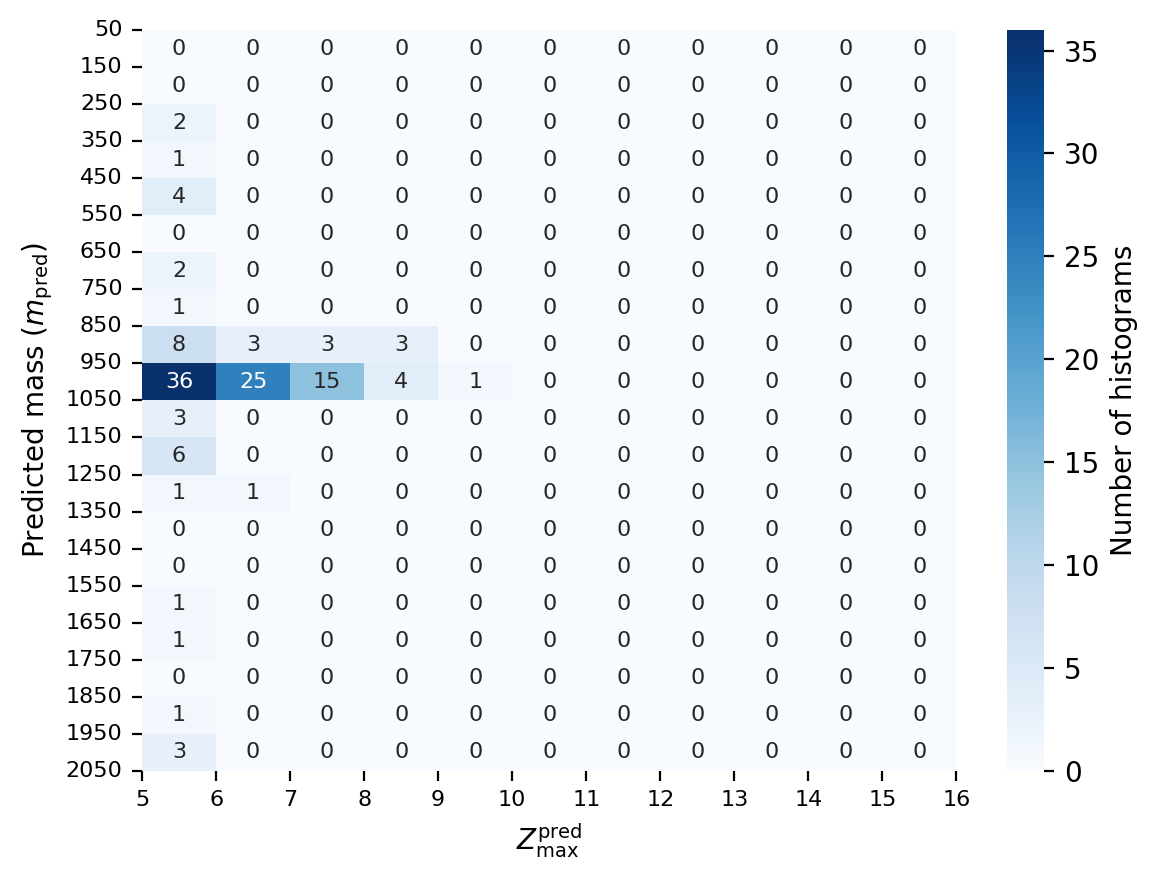

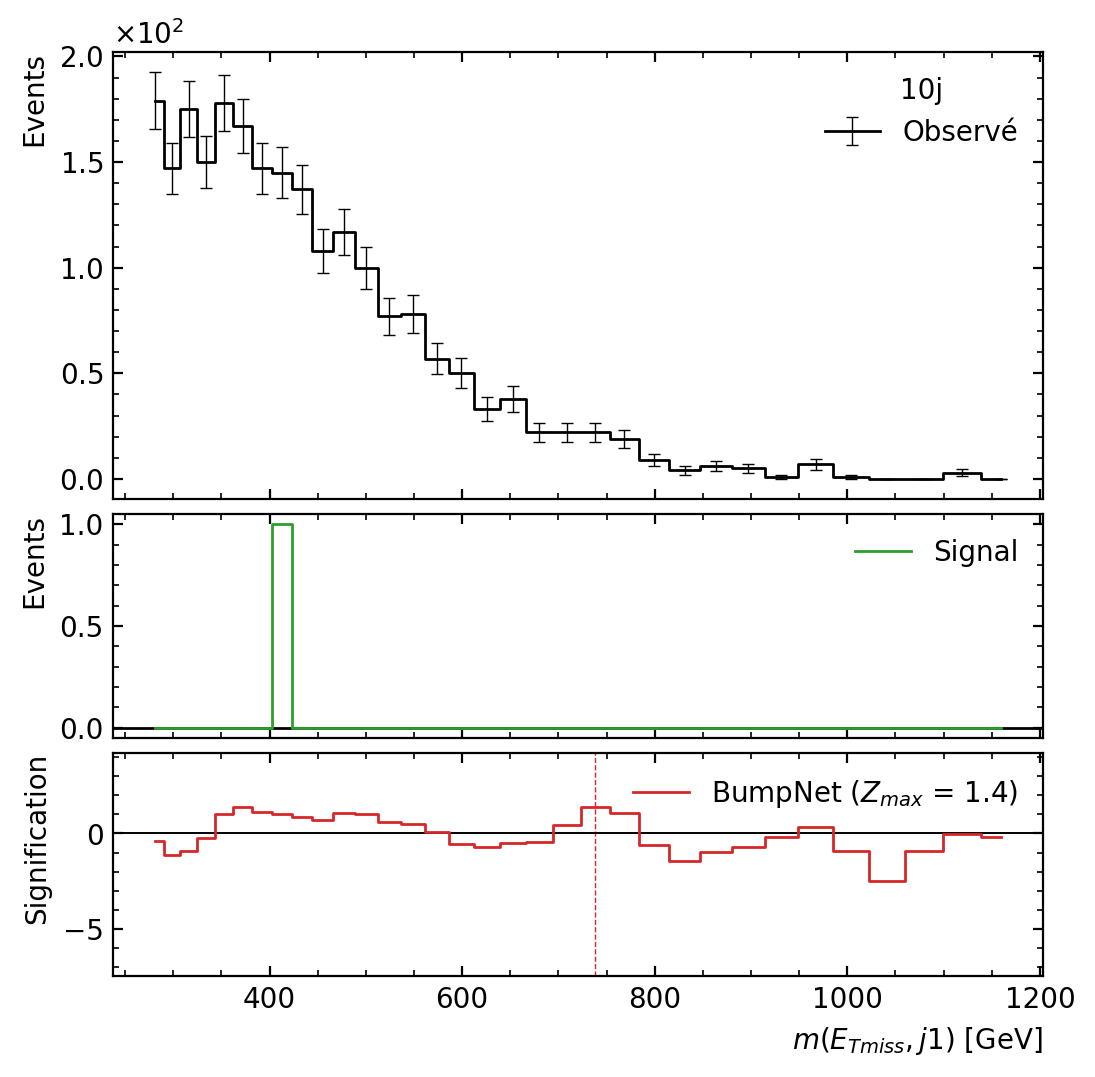

In [23]:
# *** CONFIG *** #
plot_heatmap, save_heatmap = True, False # Set to True if you want to plot the predictions heatmap and to save it
heatmap_threshold = 5 # Heatmap starting value for x axis
plot_example, save_example = True, False # Set to True if you want to plot an example and save it 
example_tag = 0 # Set to either the desired example's index or it's name
# ************** #


if type(example_tag) is str:
    idx = np.where(stop.c == "hCat_1Wh_0T_0HM_0Z_0g_0e_0m_0bExc_5ex__j2_massMET")
    print(idx)
else:
    idx = example_tag

if plot_heatmap:
    fig, _= stop.get_predictions_heatmap(threshold=heatmap_threshold)
    if save_heatmap:
        fig.savefig(f"{config['datasets'][0]['output_dir']}/heatmap_official.png", bbox_inches='tight')

if plot_example:
    fig, _ = stop.get_example(idx)
    if save_example:
        fig.savefig(f"{config['datasets'][0]['output_dir']}/example_hist_{idx}.png", bbox_inches='tight')


### Global Analysis Algorithm

First we look at an application of the global analysis algorithm when restricting objects after the algorithm and then removing families with only 1 element.

/tmp/ipykernel_904888/3611079743.py:529: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(families_mass_range, rotation=30, ha='right', fontsize=8)


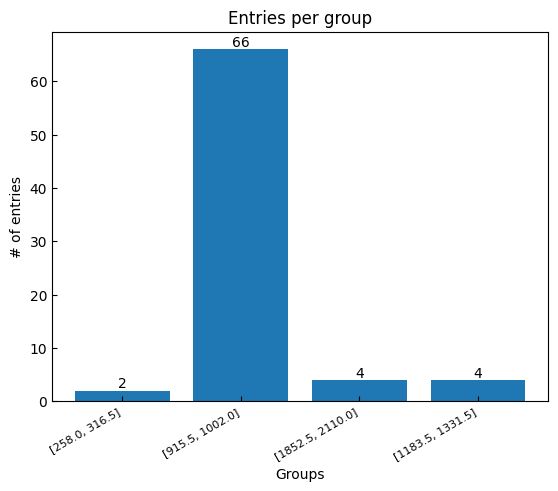

In [28]:
# Perform the GAA on the sample:
# f is the list of families, and s is the list of seeds
# sigma_treshold and bin_resolution values can be changed here:

# *** CONFIG *** #
sigma_threshold = 5
bin_resolution = 2
plot_families, save_families = True, False # Set to True if you want to -plot the families and save the figure
# ************** #

f, s = stop.perform_global_analysis_algorithm(sigma_threshold=sigma_threshold,
                                              bin_resolution=bin_resolution, verbose=False)

# This performs the majority vote and removes histograms with the wrong objects from the families
stop.restrict_objects()

# Removes families with 1 singular histogram
stop.trim_families()

# Remove family that are completely correlated (we require 2 non-correlated histograms to form a family)
stop.remove_correlated_families()

# This plots the size of the families
if plot_families:
    fig, _ = stop.plot_families()
    if save_families:
        fig.savefig(f"{config['datasets'][0]['output_dir']}/entries_per_group_official.png", bbox_inches='tight')


1591 hCat_0Wh_0T_0HM_0Z_0g_0e_0m_incl_7ex__j3_massMET
17076 hCat_1Wh_0T_0HM_0Z_0g_0e_0m_0bExc_5ex__j2_massMET


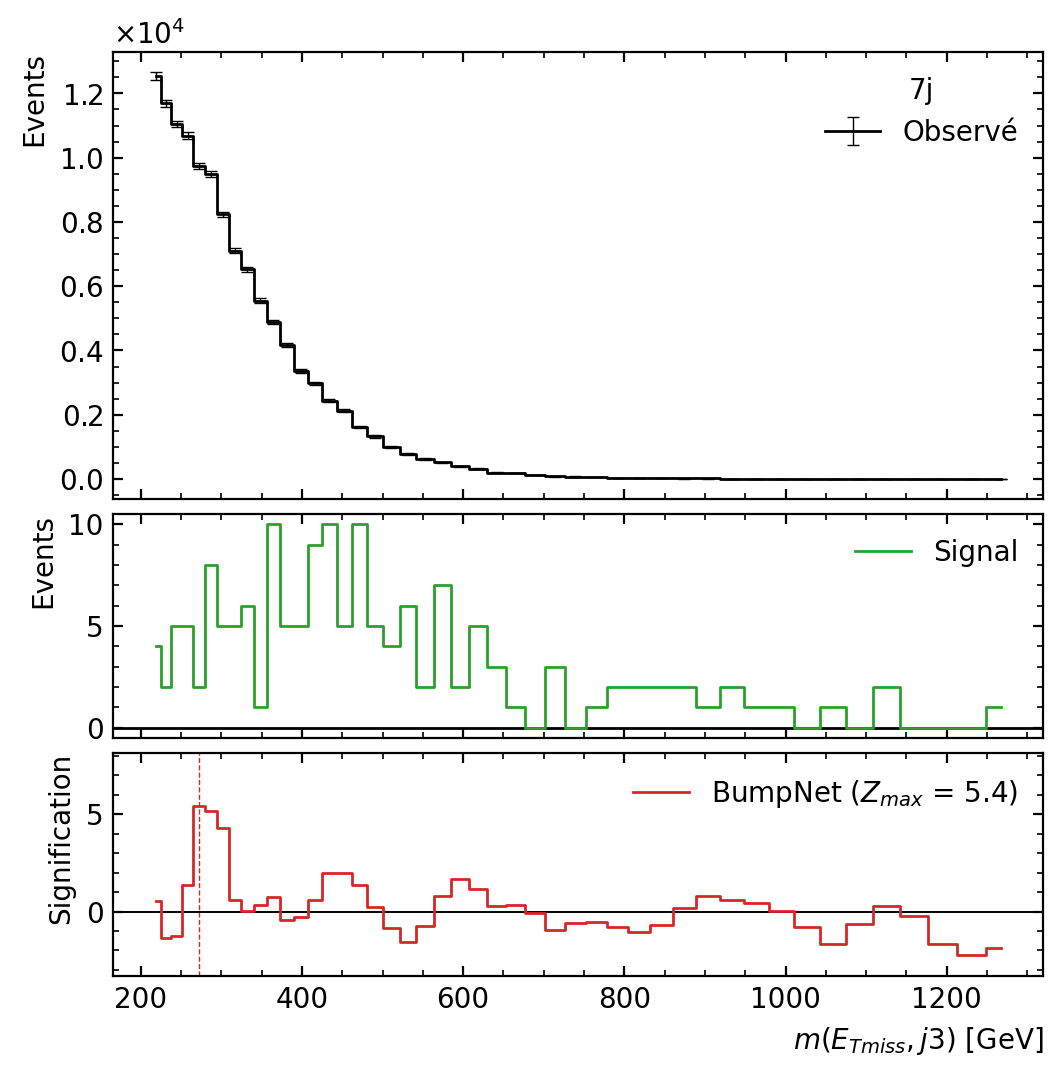

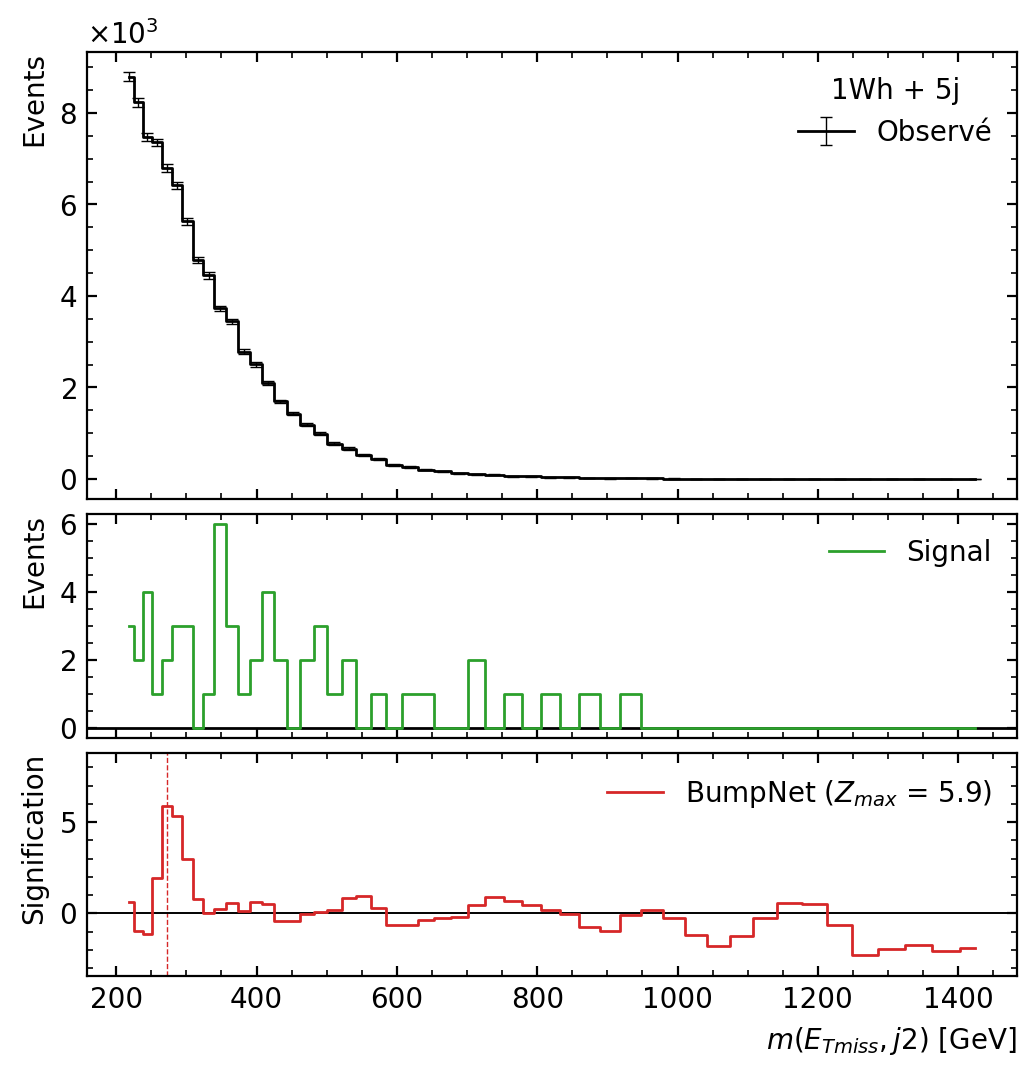

In [30]:
# This plots inidividual histograms of certain families

# *** CONFIG *** #
families_to_plot = [1] # list of indices of the families to plot
save_hists = False # Set to true if you want to save the histograms
# ************** #

stop.plot_families_contents([0], save=save_hists) # 1, 3

#### Results from GAA

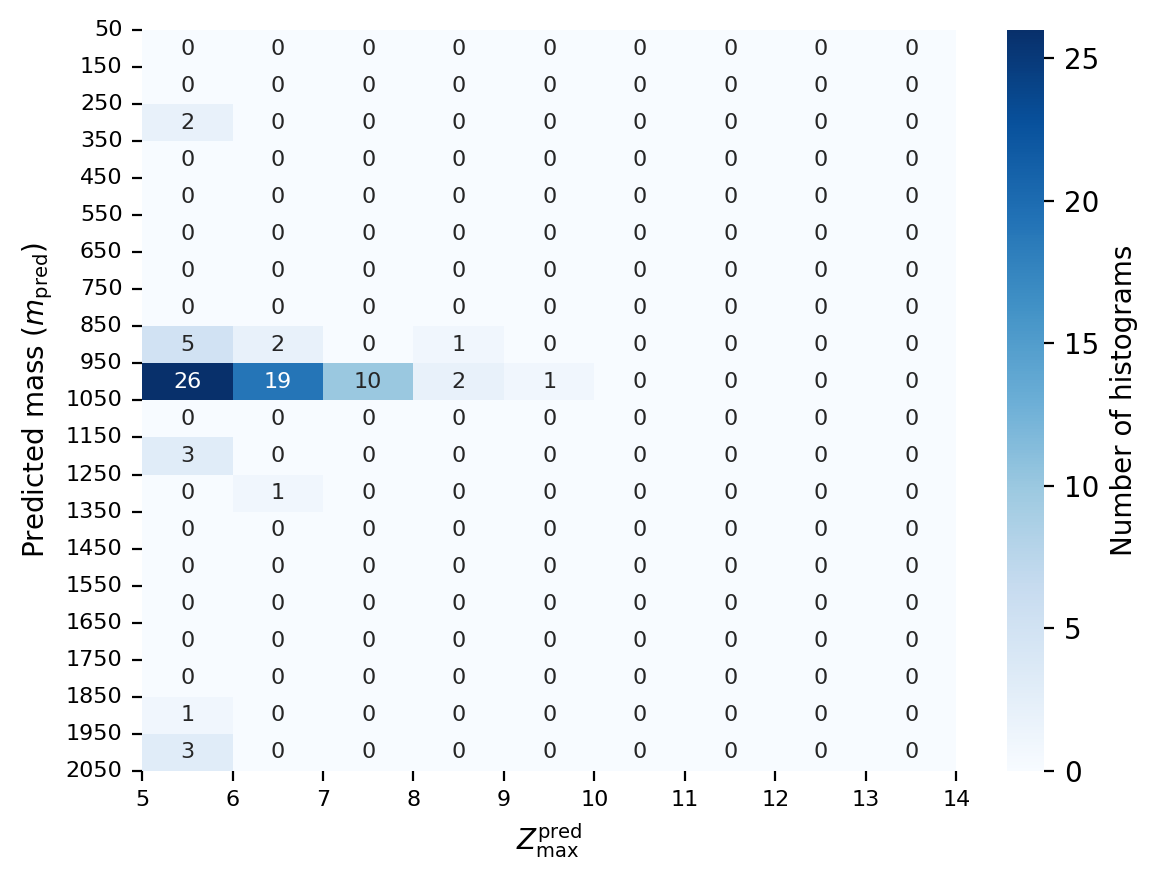

In [38]:
# This cell plots the prediction heatmap for the remaining histograms after the GAA
# *** CONFIG *** #
plot_heatmap, save_heatmap = True, True
# ************** #


# Get a list of remaining histograms to plot the heatmap
indices = []
for f in stop.families:
    for h in f.histograms:
        indices.append(h)
indices = np.array(indices)

if plot_heatmap:
    fig, _ = stop.get_predictions_heatmap(stop, 5, indices=indices)
    if save_heatmap:
        fig.savefig(f"{config['datasets'][0]['output_dir']}/heatmap_after_GAA.png", bbox_inches='tight')

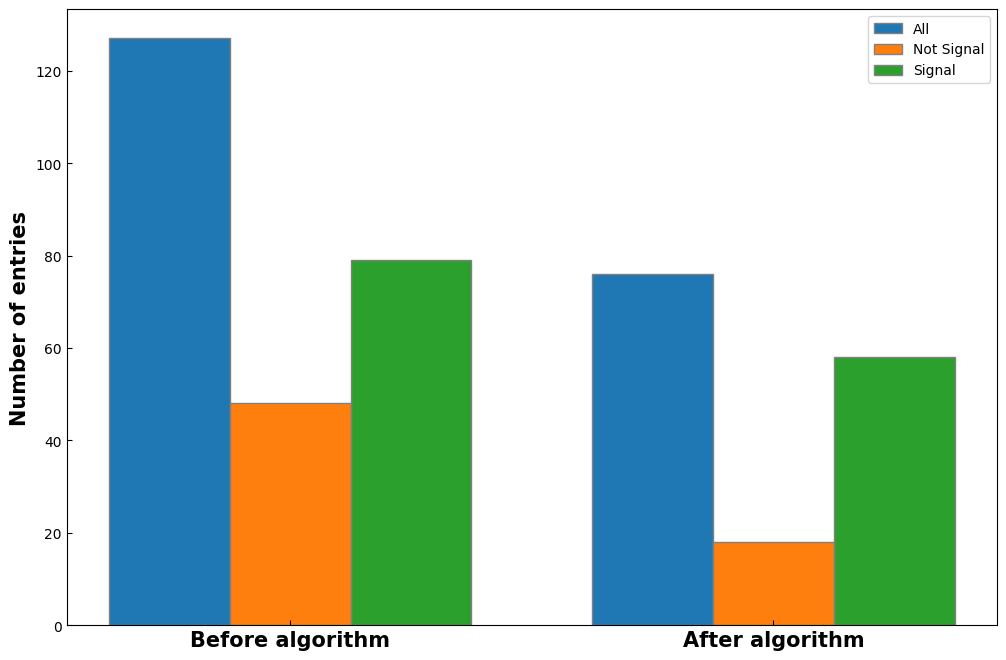

In [39]:
# This cell plots a figure that shows the number of entries before/after the GAA and allows ths user
# to tag a mass range as being the "signal"

# *** CONFIG *** #
signal_mass_inf, signal_mass_max = 950, 1050
threshold = 5
plot_gaa_effect, save_plot = True, False
# ************** #

# BEFORE GAA
# All predictions above *threshold* sigma
before_all = stop.c[stop.z_pred_max>threshold]

# All predictions above *threshold* sigma in signal range
before_signal = stop.c[(stop.z_pred_max > threshold) & (signal_mass_inf < stop.mass_pred) & (stop.mass_pred < signal_mass_max)]

# All predictions above *threshold* not in signal range
before_not_signal = before_all.size - before_signal.size


# AFTER GAA
# All unique predictons surviving GAA
after_all = np.unique(indices) # this is defined in the cell above, *CELL ABOVE NEEDS to BE RUN*

# Predictions after GAA still in signal range
after_signal = 0
for h in after_all:
    if (stop.mass_pred[h] > signal_mass_inf) and (stop.mass_pred[h] < signal_mass_max):
        # To count
        after_signal += 1

# Predictions after GAA that are not in signal range
after_not_signal = after_all.size - after_signal


# PLOT PARAMS
# set width of bar 
if plot_gaa_effect:
    barWidth = 0.25
    fig, ax = plt.subplots(figsize =(12, 8)) 
    
    # set height of bar 
    _all = [before_all.size, after_all.size] 
    not_signal = [before_not_signal, after_not_signal] 
    signal = [before_signal.size, after_signal] 
    
    # Set position of bar on X axis 
    br1 = np.arange(len(_all)) 
    br2 = [x + barWidth for x in br1] 
    br3 = [x + barWidth for x in br2] 
    
    # Make the plot
    plt.bar(br1, _all, width = barWidth, 
            edgecolor ='grey', label ='All') 
    plt.bar(br2, not_signal, width = barWidth, 
            edgecolor ='grey', label ='Not Signal') 
    plt.bar(br3, signal, width = barWidth, 
            edgecolor ='grey', label ='Signal') 
    
    # Adding Xticks 
    plt.ylabel('Number of entries', fontweight ='bold', fontsize = 15) 
    plt.xticks([r + barWidth for r in range(len(_all))], 
            ['Before algorithm', 'After algorithm'], fontweight='bold', fontsize=15)
    plt.tick_params(which='both', direction='in')
    plt.legend()
    if save_plot:
        fig.savefig(f"{config['datasets'][0]['output_dir']}/gaa_effect.png", bbox_inches='tight')